# Haptic Guidance Experiment Analysis

Loads experiment records and computed metrics from the SQLite database.
Experiments are ingested from CSV files (one per run) via `web_gui/ingest_csv.py`.

Scenario classification:
- **Training**: scenario name contains `Training`
- **Test**: scenario name contains `Test` (e.g. `Test1`, `Test2`)

Conditions recorded in each filename: `ExpertControlled`, `Control`, `WaypointGuidance`, etc.

In [1]:
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

DB_PATH       = Path("web_gui/experiments.db")
DATA_ROOT     = Path("../data_analysis")   # root containing dated result folders
WAYPOINTS_DIR = Path("waypoints")

METRICS = [
    "total_duration",
    "jitter_rms",
    "lateral_error_rms",
    "path_efficiency",
]

METRIC_LABELS = {
    "total_duration":    "Duration (s)",
    "jitter_rms":        "RMS Jitter (m)",
    "lateral_error_rms": "RMS Lateral Error (m)",
    "path_efficiency":   "Path Efficiency (%)",
}

## Discover data files

Dynamically scans `DATA_ROOT` for all participant CSVs and checks whether a matching
reference path exists in `WAYPOINTS_DIR`.
Run `web_gui/ingest_csv.py <participant_dir>` on any folder shown here to add it to the database.

In [6]:
FILENAME_RE = re.compile(
    r'^(?P<pid>[^_]+)_(?P<condition>[^_]+)_(?P<scenario>[^_]+)_'
    r'(?P<date>\d{4}-\d{2}-\d{2})_(?P<time>\d{2}-\d{2}-\d{2})\.csv$'
)

discovered = []
for csv_path in sorted(DATA_ROOT.rglob("*.csv")):
    m = FILENAME_RE.match(csv_path.name)
    if not m:
        continue
    scenario = m.group('scenario')
    ref = WAYPOINTS_DIR / f"{scenario}.csv"
    discovered.append({
        "participant":       m.group('pid'),
        "condition":         m.group('condition'),
        "scenario":          scenario,
        "date":              m.group('date'),
        "time":              m.group('time'),
        "reference_exists":  ref.exists(),
        "path":              str(csv_path),
    })

disc_df = pd.DataFrame(discovered)
print(f"Discovered {len(disc_df)} CSV file(s) across "
      f"{disc_df['participant'].nunique()} participant(s)")
print(f"Conditions : {sorted(disc_df['condition'].unique())}")
print(f"Scenarios  : {sorted(disc_df['scenario'].unique())}")
disc_df.groupby(["participant", "condition", "scenario"]).size().rename("files").reset_index()

Discovered 151 CSV file(s) across 15 participant(s)
Conditions : ['Control', 'ExpertControlled', 'WaypointGuidance']
Scenarios  : ['Test1', 'Test2', 'Training']


,participant,condition,scenario,files
0,P001,ExpertControlled,Test1,1
1,P001,ExpertControlled,Test2,1
2,P001,ExpertControlled,Training,10
3,P002,WaypointGuidance,Test1,1
4,P002,WaypointGuidance,Test2,1
5,P002,WaypointGuidance,Training,4
6,P003,ExpertControlled,Test1,1
7,P003,ExpertControlled,Test2,1
8,P003,ExpertControlled,Training,9
9,P004,WaypointGuidance,Test1,1


## Load from database

In [7]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT
            e.id,
            e.run_id,
            e.participant_id,
            e.condition,
            e.scenario,
            e.timestamp,
            e.duration,
            m.total_duration,
            m.jitter_rms,
            m.jitter_mean,
            m.jitter_std,
            m.lateral_error_rms,
            m.lateral_error_mean,
            m.lateral_error_std,
            m.path_efficiency,
            m.ideal_path_length,
            m.actual_path_length,
            m.excess_path_length
        FROM experiments e
        JOIN metrics m ON e.id = m.experiment_id
        WHERE e.status = 'completed'
        ORDER BY e.participant_id, e.condition, e.scenario, e.timestamp
    """, conn)

df["timestamp"] = pd.to_datetime(df["timestamp"])

# Classify attempt type
df["attempt_type"] = df["scenario"].apply(
    lambda s: "test" if "test" in s.lower() else "training"
)

# Attempt number within each participant+condition+scenario group
df["attempt_no"] = (
    df.groupby(["participant_id", "condition", "scenario"]).cumcount() + 1
)

print(f"{len(df)} completed experiment(s) loaded")
df.head()

151 completed experiment(s) loaded


,id,run_id,participant_id,condition,scenario,timestamp,duration,total_duration,jitter_rms,jitter_mean,jitter_std,lateral_error_rms,lateral_error_mean,lateral_error_std,path_efficiency,ideal_path_length,actual_path_length,excess_path_length,attempt_type,attempt_no
0,1,P001_ExpertControlled_Test1_2026-03-30T23-22-16,P001,ExpertControlled,Test1,2026-03-30 23:22:16,6.7157,6.7157,0.001170,0.000904,0.000743,0.051237,0.043318,0.027365,90.758007,1.040654,1.146625,0.105971,test,1
1,2,P001_ExpertControlled_Test2_2026-03-30T23-24-00,P001,ExpertControlled,Test2,2026-03-30 23:24:00,6.9766,6.9766,0.001127,0.000926,0.000642,0.060975,0.053498,0.029256,94.080709,1.145856,1.217950,0.072094,test,1
2,3,P001_ExpertControlled_Training_2026-03-30T23-2...,P001,ExpertControlled,Training,2026-03-30 23:21:05,8.9530,8.9530,0.001424,0.001123,0.000876,0.081682,0.061565,0.053681,66.236845,1.164916,1.758713,0.593797,training,1
3,4,P001_ExpertControlled_Training_2026-03-30T23-2...,P001,ExpertControlled,Training,2026-03-30 23:21:20,5.6566,5.6566,0.001789,0.001360,0.001162,0.061855,0.048020,0.038988,78.816730,1.164916,1.478006,0.313090,training,2
4,5,P001_ExpertControlled_Training_2026-03-30T23-2...,P001,ExpertControlled,Training,2026-03-30 23:21:34,3.7981,3.7981,0.003562,0.002091,0.002884,0.076217,0.053476,0.054308,71.168202,1.164916,1.636849,0.471933,training,3


## Overview

In [8]:
print("Participants:", sorted(df["participant_id"].unique()))
print("Conditions:  ", sorted(df["condition"].unique()))
print("Scenarios:   ", sorted(df["scenario"].unique()))
print()
df.groupby(["participant_id", "condition", "scenario"]).size().rename("attempts").reset_index()

Participants: ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015']
Conditions:   ['Control', 'ExpertControlled', 'WaypointGuidance']
Scenarios:    ['Test1', 'Test2', 'Training']



,participant_id,condition,scenario,attempts
0,P001,ExpertControlled,Test1,1
1,P001,ExpertControlled,Test2,1
2,P001,ExpertControlled,Training,10
3,P002,WaypointGuidance,Test1,1
4,P002,WaypointGuidance,Test2,1
5,P002,WaypointGuidance,Training,4
6,P003,ExpertControlled,Test1,1
7,P003,ExpertControlled,Test2,1
8,P003,ExpertControlled,Training,9
9,P004,WaypointGuidance,Test1,1


## Training progression — metric over attempts

One line per participant per condition. Set filters to `None` to show all.

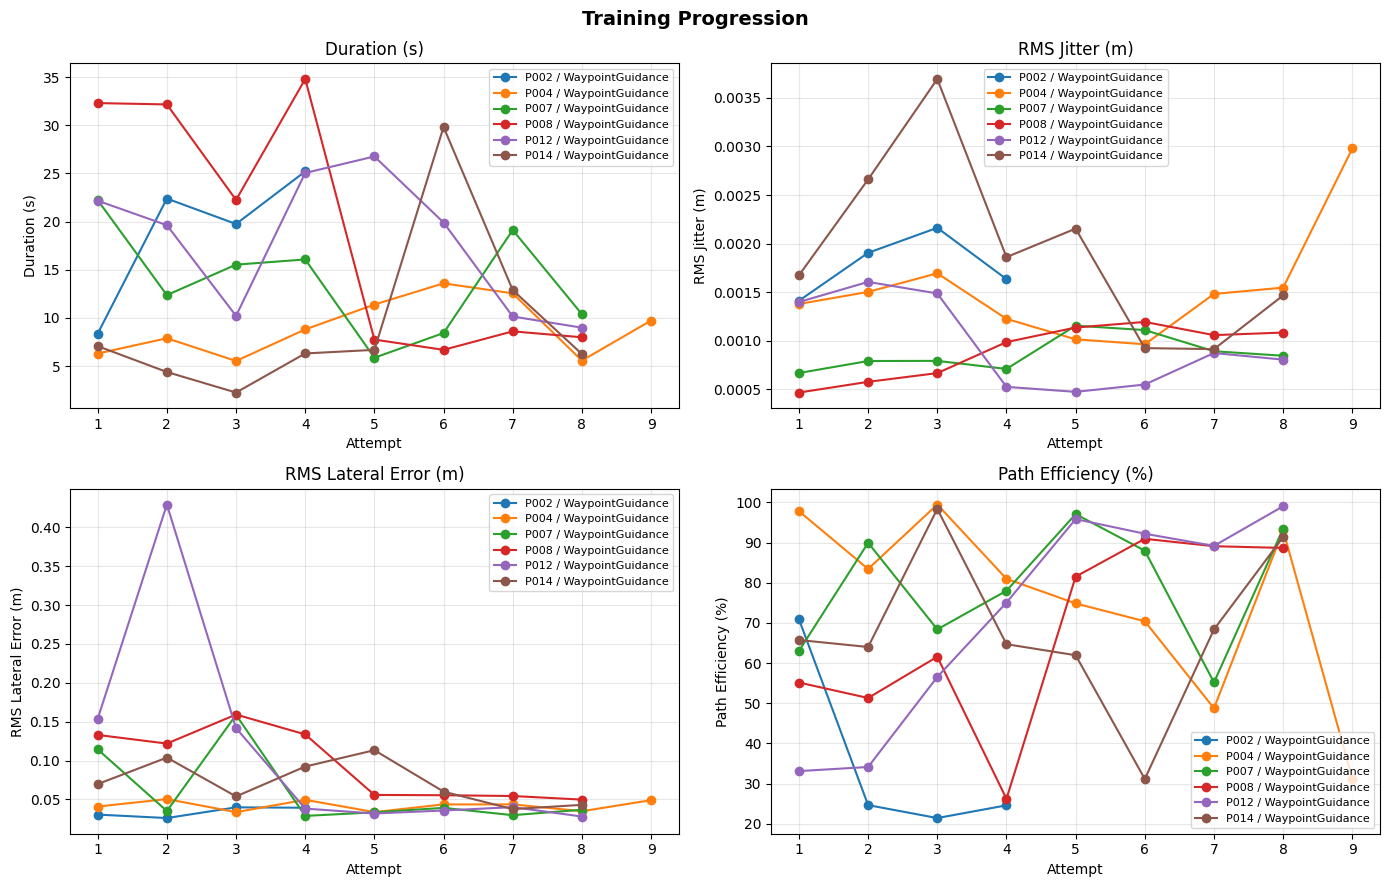

In [16]:
PARTICIPANT = None   # e.g. "P001"
CONDITION   = "WaypointGuidance"   # e.g. "ExpertControlled"

train = df[df["attempt_type"] == "training"].copy()
if PARTICIPANT:
    train = train[train["participant_id"] == PARTICIPANT]
if CONDITION:
    train = train[train["condition"] == CONDITION]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Training Progression", fontsize=14, fontweight="bold")

for ax, metric in zip(axes.flat, METRICS):
    for (pid, cond, sc), group in train.groupby(["participant_id", "condition", "scenario"]):
        ax.plot(group["attempt_no"], group[metric], marker="o", label=f"{pid} / {cond}")
    ax.set_xlabel("Attempt")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Performance trend — individual lines + group aggregate

Each participant is a thin line. The bold line is the group mean; the shaded band is ±1 std.

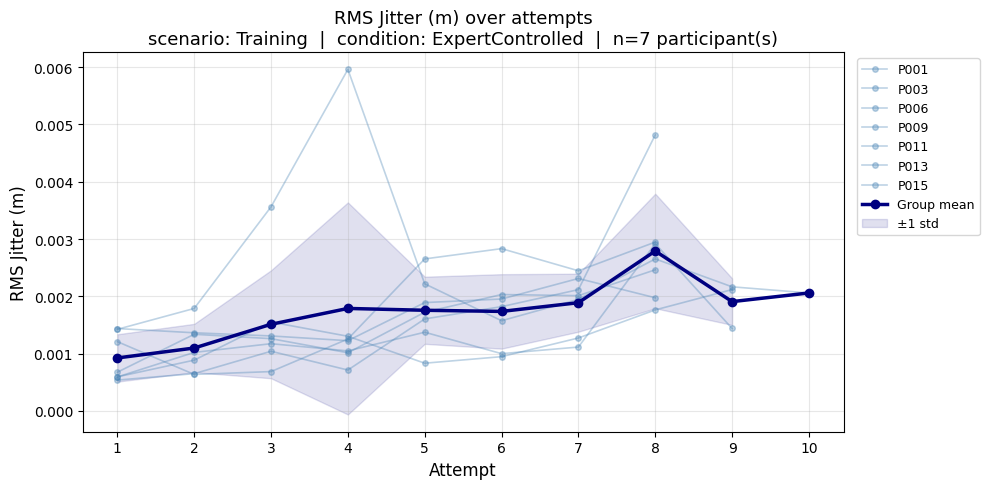

In [25]:
METRIC       = "jitter_rms"   # one of METRICS
CONDITION    = "ExpertControlled"               # e.g. "ExpertControlled", or None for all
SCENARIO     = "Training"         # e.g. "Training", "Test1", "Test2"
ATTEMPT_TYPE = "training"         # "training" or "test"

subset = df[df["attempt_type"] == ATTEMPT_TYPE].copy()
if CONDITION:
    subset = subset[subset["condition"] == CONDITION]
if SCENARIO:
    subset = subset[subset["scenario"] == SCENARIO]

if subset.empty:
    print(f"No data for scenario='{SCENARIO}', condition='{CONDITION}', attempt_type='{ATTEMPT_TYPE}'")
else:
    pivot = subset.pivot_table(
        index="attempt_no", columns="participant_id",
        values=METRIC, aggfunc="first"
    )
    agg_mean = pivot.mean(axis=1)
    agg_std  = pivot.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))
    for pid in pivot.columns:
        ax.plot(pivot.index, pivot[pid],
                color="steelblue", alpha=0.35, linewidth=1.2,
                marker="o", markersize=4, label=pid)
    ax.plot(agg_mean.index, agg_mean,
            color="navy", linewidth=2.5, marker="o", markersize=6,
            label="Group mean", zorder=5)
    ax.fill_between(agg_mean.index, agg_mean - agg_std, agg_mean + agg_std,
                    color="navy", alpha=0.12, label="±1 std")

    title_cond = CONDITION or "all conditions"
    ax.set_xlabel("Attempt", fontsize=12)
    ax.set_ylabel(METRIC_LABELS[METRIC], fontsize=12)
    ax.set_title(
        f"{METRIC_LABELS[METRIC]} over attempts\n"
        f"scenario: {SCENARIO}  |  condition: {title_cond}  |  n={pivot.shape[1]} participant(s)",
        fontsize=13
    )
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Test results — metric over attempts

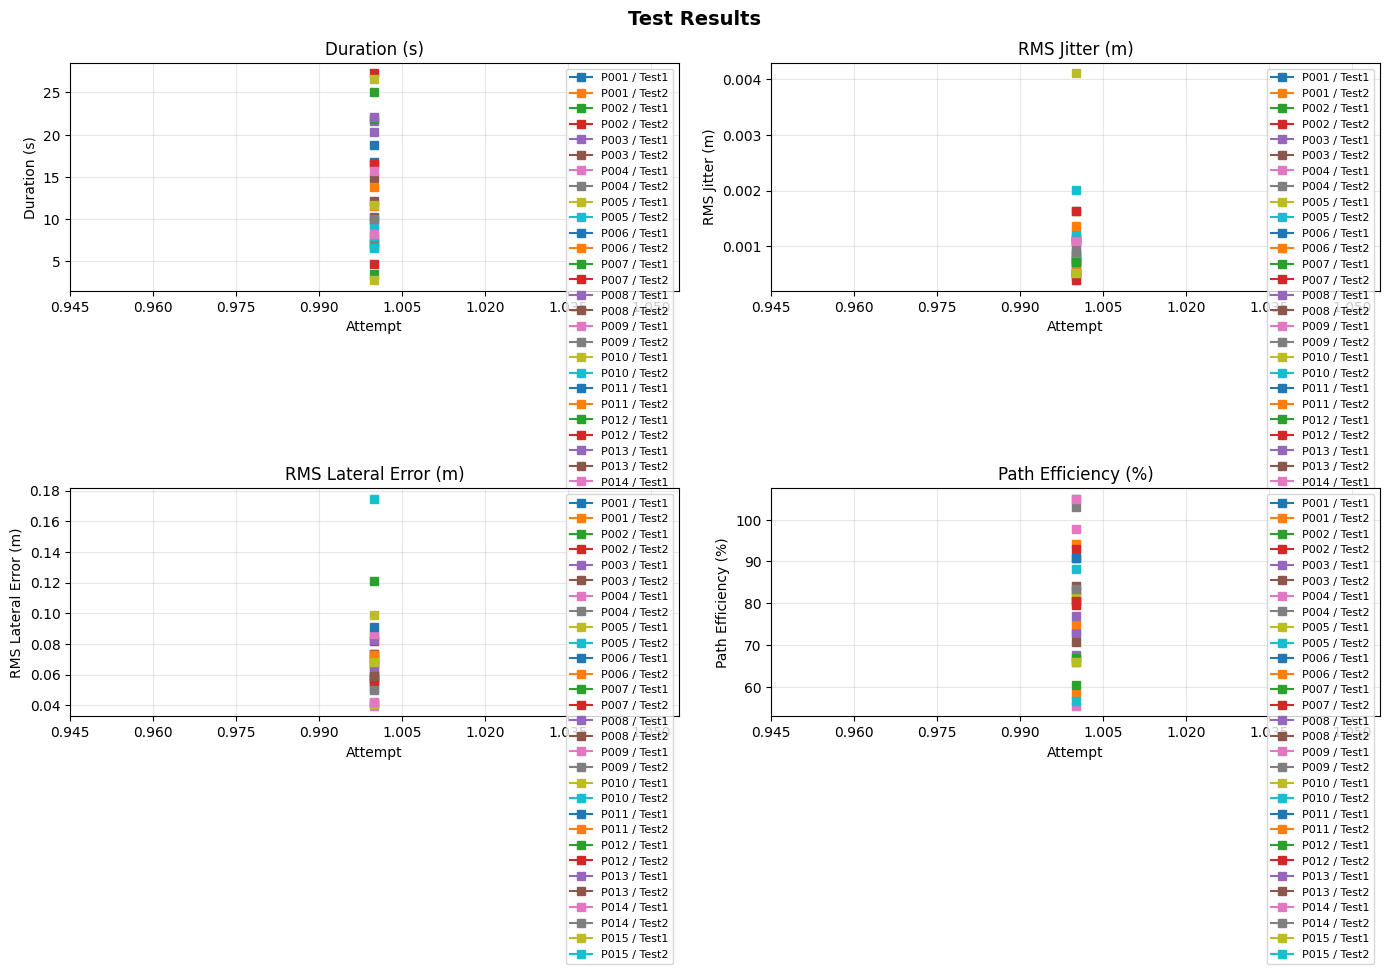

In [11]:
PARTICIPANT = None   # e.g. "P001"
CONDITION   = None   # e.g. "ExpertControlled"

test = df[df["attempt_type"] == "test"].copy()
if PARTICIPANT:
    test = test[test["participant_id"] == PARTICIPANT]
if CONDITION:
    test = test[test["condition"] == CONDITION]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Test Results", fontsize=14, fontweight="bold")

for ax, metric in zip(axes.flat, METRICS):
    for (pid, cond, sc), group in test.groupby(["participant_id", "condition", "scenario"]):
        ax.plot(group["attempt_no"], group[metric], marker="s", label=f"{pid} / {sc}")
    ax.set_xlabel("Attempt")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Condition comparison

Mean metrics per condition, split by scenario (test runs by default).
Each bar group is one condition; bars within a group are the test scenarios.

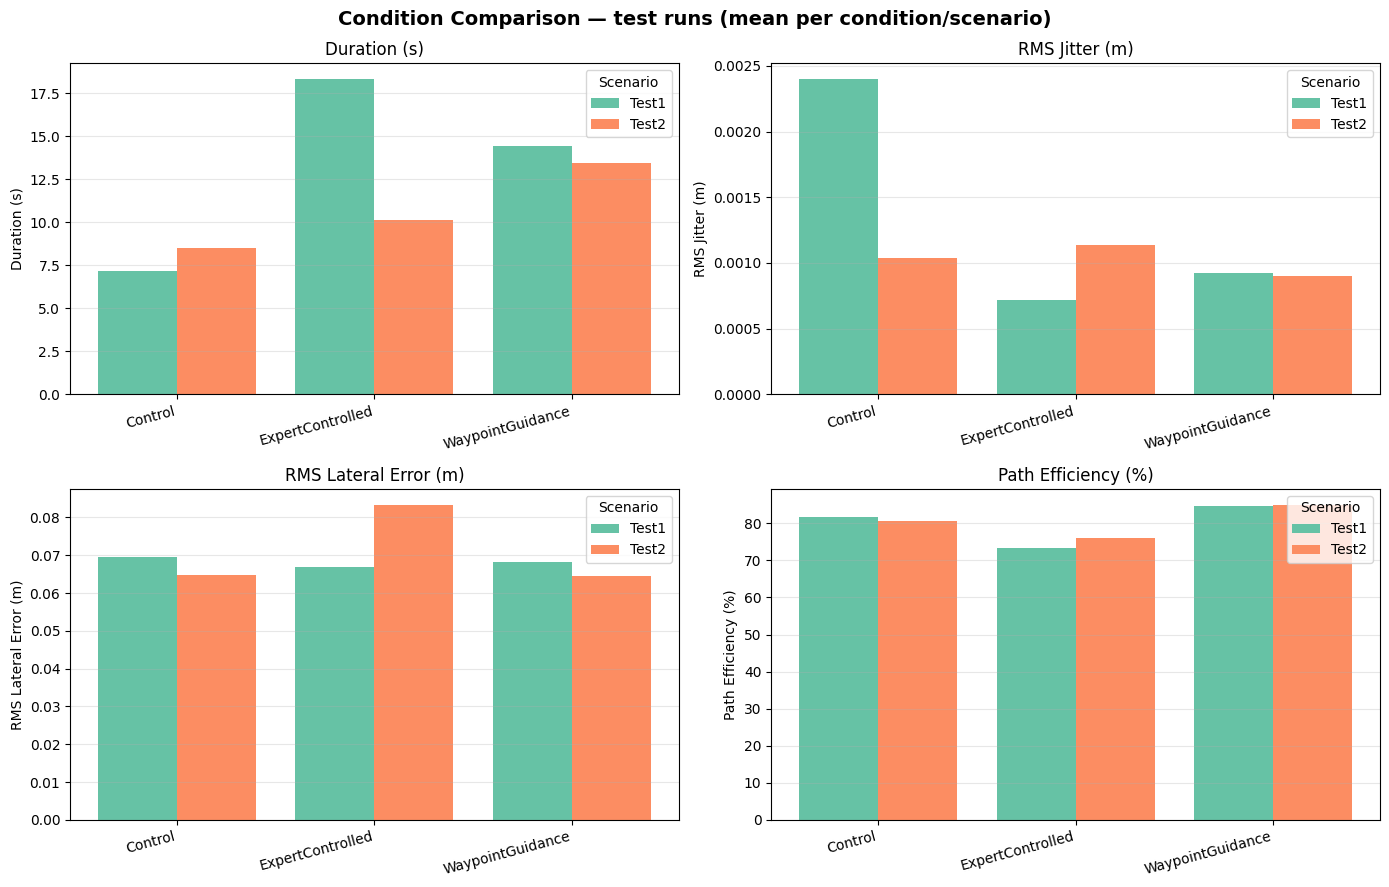

In [ ]:
ATTEMPT_TYPE = "test"   # "training" or "test"

subset = df[df["attempt_type"] == ATTEMPT_TYPE].copy()
conditions = sorted(subset["condition"].unique())
scenarios  = sorted(subset["scenario"].unique())

summary = (
    subset.groupby(["condition", "scenario"])[METRICS]
    .agg(["mean", "std"])
    .reset_index()
)

x          = range(len(conditions))
n_scenarios = len(scenarios)
width       = 0.8 / n_scenarios
colours     = plt.cm.Set2.colors

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    f"Condition Comparison — {ATTEMPT_TYPE} runs (mean ± std per condition/scenario)",
    fontsize=14, fontweight="bold"
)

for ax, metric in zip(axes.flat, METRICS):
    for i, sc in enumerate(scenarios):
        means, errs = [], []
        for cond in conditions:
            row = summary.loc[
                (summary["condition"] == cond) & (summary["scenario"] == sc)
            ]
            means.append(row[(metric, "mean")].values[0] if not row.empty else float("nan"))
            errs.append(row[(metric, "std")].values[0]  if not row.empty else float("nan"))
        offset = (i - (n_scenarios - 1) / 2) * width
        ax.bar(
            [xi + offset for xi in x], means, width,
            yerr=errs, capsize=4, error_kw={"elinewidth": 1.2, "ecolor": "black"},
            label=sc, color=colours[i % len(colours)]
        )
    ax.set_xticks(list(x))
    ax.set_xticklabels(conditions, rotation=15, ha="right")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.legend(title="Scenario")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Per-participant summary table

In [9]:
df.groupby(["participant_id", "condition", "scenario"])[METRICS].agg(["mean", "std"]).round(4)

total_duration         jitter_rms  \
                                                   mean     std       mean   
participant_id condition        scenario                                     
P001           ExpertControlled Test1            6.7157     NaN     0.0012   
                                Test2            6.9766     NaN     0.0011   
                                Training         5.5628  2.0959     0.0025   

                                                 lateral_error_rms          \
                                             std              mean     std   
participant_id condition        scenario                                     
P001           ExpertControlled Test1        NaN            0.0512     NaN   
                                Test2        NaN            0.0610     NaN   
                                Training  0.0013            0.0695  0.0232   

                                         path_efficiency          
                                                    mean     std  
participant_id condition        scenario                          
P001           ExpertControlled Test1            90.7580     NaN  
                                Test2            94.0807     NaN  
                                Training         75.6267  12.991

## Raw data export

In [10]:
# Uncomment to export to CSV
# df.to_csv("experiment_results.csv", index=False)
# print("Exported to experiment_results.csv")